# Eda for solar eclipse 


In [41]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("data/solar.csv")

df.head()



,Catalog Number,Calendar Date,Eclipse Time,Delta T (s),Lunation Number,Saros Number,Eclipse Type,Gamma,Eclipse Magnitude,Latitude,Longitude,Sun Altitude,Sun Azimuth,Path Width (km),Central Duration
0,1,-1999 June 12,03:14:51,46438,-49456,5,T,-0.2701,1.0733,6.0N,33.3W,74,344,247,06m37s
1,2,-1999 December 5,23:45:23,46426,-49450,10,A,-0.2317,0.9382,32.9S,10.8E,76,21,236,06m44s
2,3,-1998 June 1,18:09:16,46415,-49444,15,T,0.4994,1.0284,46.2N,83.4E,60,151,111,02m15s
3,4,-1998 November 25,05:57:03,46403,-49438,20,A,-0.9045,0.9806,67.8S,143.8W,25,74,162,01m14s
4,5,-1997 April 22,13:19:56,46393,-49433,-13,P,-1.4670,0.1611,60.6S,106.4W,0,281,NaN,NaN


In [42]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11898 entries, 0 to 11897
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Catalog Number     11898 non-null  int64  
 1   Calendar Date      11898 non-null  str    
 2   Eclipse Time       11898 non-null  str    
 3   Delta T (s)        11898 non-null  int64  
 4   Lunation Number    11898 non-null  int64  
 5   Saros Number       11898 non-null  int64  
 6   Eclipse Type       11898 non-null  str    
 7   Gamma              11898 non-null  float64
 8   Eclipse Magnitude  11898 non-null  float64
 9   Latitude           11898 non-null  str    
 10  Longitude          11898 non-null  str    
 11  Sun Altitude       11898 non-null  int64  
 12  Sun Azimuth        11898 non-null  int64  
 13  Path Width (km)    7698 non-null   str    
 14  Central Duration   7698 non-null   str    
dtypes: float64(2), int64(6), str(7)
memory usage: 1.8 MB


In [43]:
df.isna().sum()

Catalog Number          0
Calendar Date           0
Eclipse Time            0
Delta T (s)             0
Lunation Number         0
Saros Number            0
Eclipse Type            0
Gamma                   0
Eclipse Magnitude       0
Latitude                0
Longitude               0
Sun Altitude            0
Sun Azimuth             0
Path Width (km)      4200
Central Duration     4200
dtype: int64

In [44]:
df.describe()

,Catalog Number,Delta T (s),Lunation Number,Saros Number,Gamma,Eclipse Magnitude,Sun Altitude,Sun Azimuth
count,11898.000000,11898.000000,11898.000000,11898.000000,11898.000000,11898.000000,11898.000000,11898.000000
mean,5949.500000,12142.172802,-18546.959321,87.483190,-0.002469,0.812748,36.505295,180.264330
std,3434.801086,13583.402888,17906.572982,48.380284,0.900860,0.300398,32.417350,110.745408
min,1.000000,-6.000000,-49456.000000,-13.000000,-1.569000,0.000000,0.000000,0.000000
25%,2975.250000,970.250000,-33954.750000,47.000000,-0.786575,0.675925,0.000000,89.000000
50%,5949.500000,5636.500000,-18495.000000,87.000000,-0.003850,0.950600,38.000000,180.000000
75%,8923.750000,20943.500000,-3039.250000,128.000000,0.776900,1.018400,66.000000,272.000000
max,11898.000000,46438.000000,12378.000000,190.000000,1.570600,1.081300,90.000000,360.000000


## Basic cleaning

just changing to snake case

In [45]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace(r"[()]", "", regex=True)
)

Plotting diffrent types

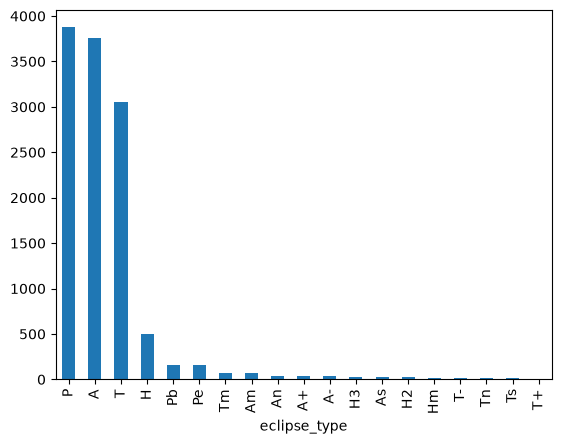

In [46]:
df["eclipse_type"].value_counts().plot(kind="bar")
plt.show()

In [47]:
df["year"] = df["calendar_date"].str.split(" ").str[0].astype(int)
df["year"].head()

0   -1999
1   -1999
2   -1998
3   -1998
4   -1997
Name: year, dtype: int64

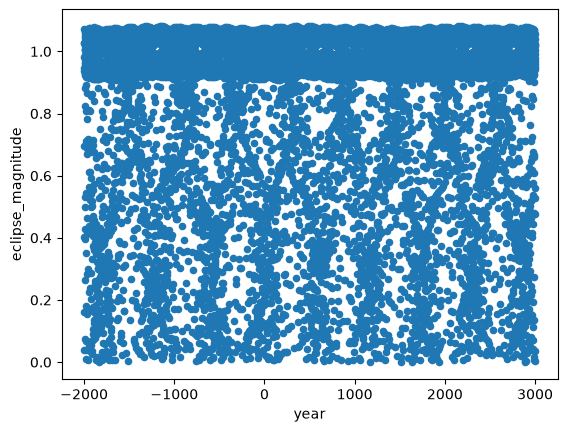

In [48]:
df.plot(x="year", y="eclipse_magnitude", kind="scatter")
plt.xlabel("year")
plt.ylabel("eclipse_magnitude")
plt.show()

plotting relevant years

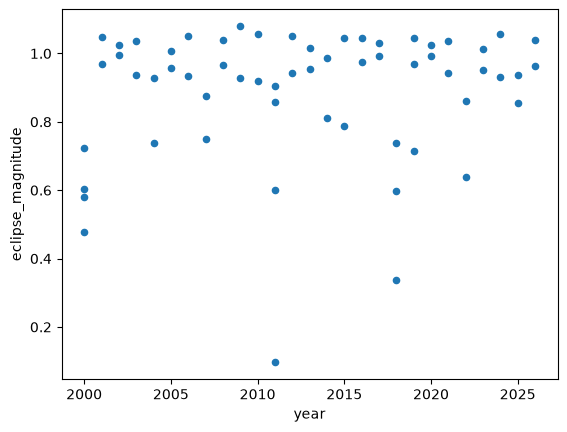

In [53]:
df_recent = df[(df["year"] >= 2000) & (df["year"] <= 2026)]

df_recent.plot(x="year", y="eclipse_magnitude", kind="scatter")
plt.xlabel("year")
plt.ylabel("eclipse_magnitude")
plt.show()

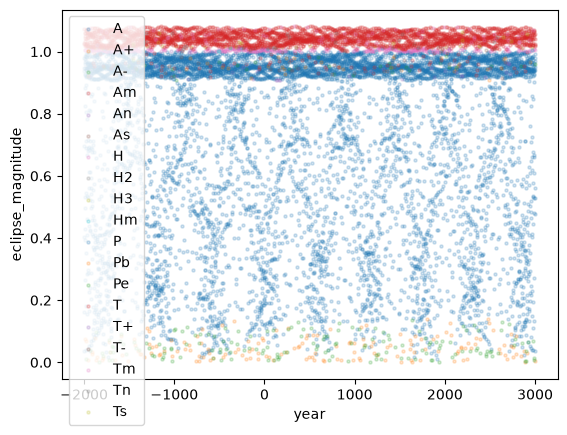

In [49]:
fig, ax = plt.subplots()
for etype, group in df.groupby("eclipse_type"):
    ax.scatter(group["year"], group["eclipse_magnitude"], alpha=0.2, s=5, label=etype)
ax.set_xlabel("year")
ax.set_ylabel("eclipse_magnitude")
ax.legend()
plt.show()

In [50]:
def convert_coord(val):
    direction = val[-1]
    number = float(val[:-1])
    return -number if direction in ["S", "W"] else number

df["lat"] = df["latitude"].apply(convert_coord)
df["lon"] = df["longitude"].apply(convert_coord)


In [51]:
df["path_width_km"].unique()

<ArrowStringArray>
[ '247',  '236',  '111',  '162',    nan,  '277',  '101',   '45',   '85',
  '186',
 ...
  '691',  '674',  '704',  '893',  '586',  '408',  '507',  '510',  '504',
 '1130']
Length: 755, dtype: str

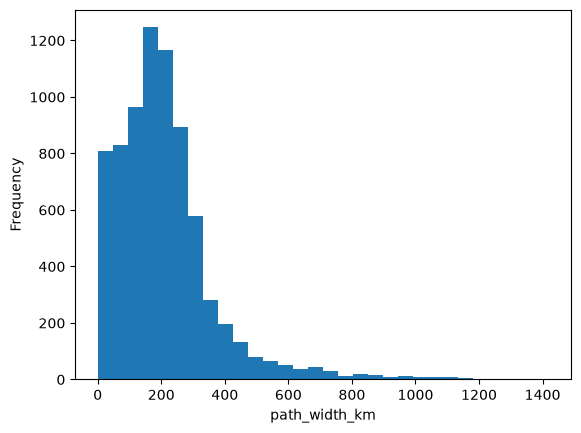

In [52]:
path_width = df["path_width_km"].replace("-", pd.NA).dropna().astype(float)

path_width.plot(kind="hist", bins=30)
plt.xlabel("path_width_km")
plt.show()